Slope (m): 10.000000000000002
Intercept (b): -1.4210854715202004e-14


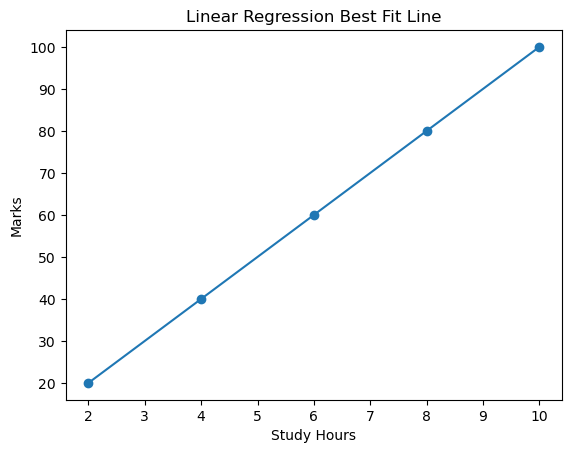

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Independent variable (X)
X = np.array([2, 4, 6, 8, 10]).reshape(-1, 1)

# Dependent variable (y)
y = np.array([20, 40, 60, 80, 100])

model = LinearRegression()

model.fit(X, y)

slope = model.coef_[0]
intercept = model.intercept_

print("Slope (m):", slope)
print("Intercept (b):", intercept)

y_pred = model.predict(X)

plt.scatter(X, y)          # Actual data points
plt.plot(X, y_pred)        # Best fit line
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Linear Regression Best Fit Line")
plt.show()

Actual Values: [ 20  40  60  80 100]
Predicted (High Bias Model): [60 60 60 60 60]
Mean Value Used: 60.0
MSE (Error): 800.0


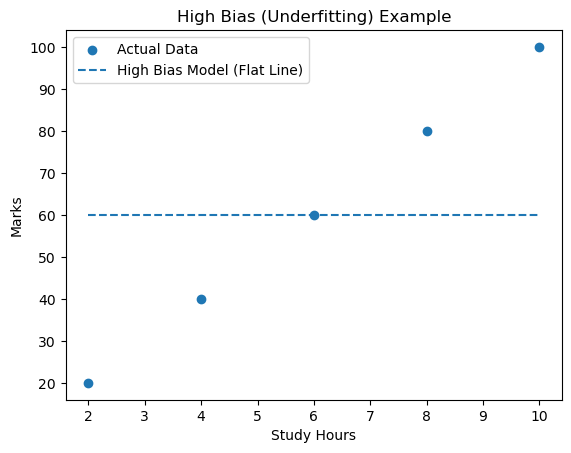

In [2]:
# 🔹 High Bias (Underfitting) Example - Single Code Cell

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Step 1: Dataset (Study Hours vs Marks)
X = np.array([2, 4, 6, 8, 10]).reshape(-1, 1)
y = np.array([20, 40, 60, 80, 100])

# Step 2: High Bias Model (Constant Prediction)
# Instead of learning slope, we force model to predict mean
y_mean = np.mean(y)
y_pred_bias = np.full_like(y, y_mean)

# Step 3: Calculate Error (MSE)
mse = mean_squared_error(y, y_pred_bias)

# Step 4: Print Results
print("Actual Values:", y)
print("Predicted (High Bias Model):", y_pred_bias)
print("Mean Value Used:", y_mean)
print("MSE (Error):", mse)

# Step 5: Visualization
plt.scatter(X, y, label="Actual Data")
plt.plot(X, y_pred_bias, linestyle='--', label="High Bias Model (Flat Line)")
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("High Bias (Underfitting) Example")
plt.legend()
plt.show()

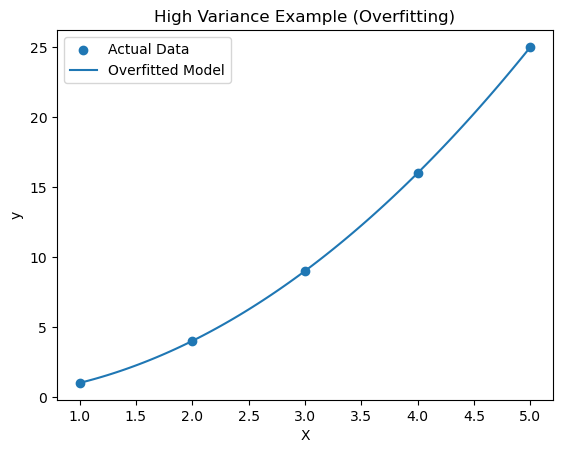

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Dataset
X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
y = np.array([1, 4, 9, 16, 25])

# Create high-degree polynomial features
poly = PolynomialFeatures(degree=4)   # high complexity
X_poly = poly.fit_transform(X)

# Train model
model = LinearRegression()
model.fit(X_poly, y)

# Smooth curve for plotting
X_range = np.linspace(1, 5, 100).reshape(-1, 1)
X_range_poly = poly.transform(X_range)
y_pred = model.predict(X_range_poly)

# Plot
plt.scatter(X, y, label="Actual Data")
plt.plot(X_range, y_pred, label="Overfitted Model")

plt.xlabel("X")
plt.ylabel("y")
plt.title("High Variance Example (Overfitting)")
plt.legend()
plt.show()

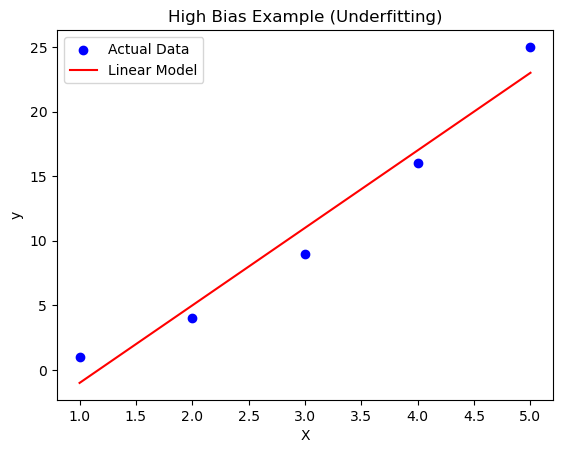

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Dataset
X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
y = np.array([1, 4, 9, 16, 25])   # y = x^2

# Train Linear Model (simple model)
model = LinearRegression()
model.fit(X, y)

# Predictions
y_pred = model.predict(X)

# Plot
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, y_pred, color='red', label='Linear Model')

plt.xlabel("X")
plt.ylabel("y")
plt.title("High Bias Example (Underfitting)")
plt.legend()
plt.show()

Training R² Score: 0.994
Cross Validation Scores: [0.991 0.997 0.98  0.977 0.996]
Average CV R² Score: 0.988
Result: Balanced Model (Good Fit)


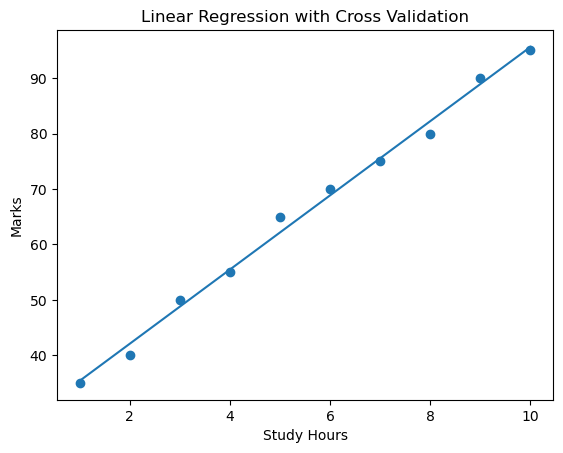

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
import matplotlib.pyplot as plt

# Step 1: Create Dataset
data = {
    'Hours': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Marks': [35, 40, 50, 55, 65, 70, 75, 80, 90, 95]
}

df = pd.DataFrame(data)
X = df[['Hours']]
y = df['Marks']

# Step 2: Train Model
model = LinearRegression()
model.fit(X, y)

# Step 3: Training Score (Bias Indicator)
train_score = model.score(X, y)

# Step 4: K-Fold Cross Validation (Variance Indicator)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')
cv_mean = np.mean(cv_scores)

# Step 5: Print Scores
print("Training R² Score:", round(train_score, 3))
print("Cross Validation Scores:", np.round(cv_scores, 3))
print("Average CV R² Score:", round(cv_mean, 3))

# Step 6: Bias vs Variance Decision
if train_score < 0.7 and cv_mean < 0.7:
    print("Result: High Bias (Underfitting)")
elif train_score > 0.9 and (train_score - cv_mean) > 0.2:
    print("Result: High Variance (Overfitting)")
else:
    print("Result: Balanced Model (Good Fit)")

# Step 7: Plot Best Fit Line
plt.scatter(X, y)
plt.plot(X, model.predict(X))
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Linear Regression with Cross Validation")
plt.show()